<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/LinearSVMTextClassificationweek_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  CN7030 — Assessment Lab
# Salik Ram Bhandari
# 3260364
## Week 10: Text Classification with PySpark — Linear SVM on IMDB Movie Reviews


So the biggest adaptation vs. the Guided Lab is **Section 4 (Data Ingestion)** — everything downstream
(preprocessing → TF-IDF → Linear SVM → evaluation) follows the same pipeline architecture you already
built for AG News.


---
## Section 1 — Pipeline Architecture Overview

```
 aclImdb_v1.tar.gz (train/pos, train/neg, test/pos, test/neg .txt files)
    │
    ▼
┌─────────────────────────────────────────────────────────┐
│  DATA INGESTION  (walk folders → Spark DataFrame)        │
│  text = file contents, label = 1 (pos) / 0 (neg)          │
└───────────────────────────┬─────────────────────────────┘
                            ▼
┌─────────────────────────────────────────────────────────┐
│  PREPROCESSING                                            │
│  • Strip HTML (IMDB reviews contain <br /> tags)          │
│  • Lowercase • Remove punctuation/non-alpha • Trim         │
└───────────────────────────┬─────────────────────────────┘
                            ▼
┌─────────────────────────────────────────────────────────┐
│  FEATURE ENGINEERING (TF-IDF)                              │
│  Tokenizer → StopWordsRemover → HashingTF → IDF            │
└───────────────────────────┬─────────────────────────────┘
                            ▼
┌─────────────────────────────────────────────────────────┐
│  MODEL TRAINING — Linear SVM (LinearSVC)                   │
└───────────────────────────┬─────────────────────────────┘
                            ▼
┌─────────────────────────────────────────────────────────┐
│  EVALUATION — Accuracy, Precision, Recall, F1, Confusion   │
│  Matrix                                                     │
└─────────────────────────────────────────────────────────┘
```


---
##  Section 2 — Environment Setup

Run the cell below to install PySpark and import all required libraries.
This only needs to be done **once per Colab session**.


In [5]:
# ── Install PySpark (Colab only)
!pip install -q pyspark

# ── Standard library imports
import os
import re
import tarfile
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── PySpark imports
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.sql.functions import col, lower, regexp_replace, trim
from pyspark.ml import Pipeline
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml.classification import LinearSVC
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

print('  Libraries imported.')


  Libraries imported.


---
##  Section 3 — Initialise Spark Session

Same configuration as the Guided Lab — local mode, using all available CPU cores.


In [6]:
spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('CN7030_AssessmentLab_IMDB_SVM')
    .config('spark.driver.memory', '4g')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')  # suppress INFO noise

print(f'  Spark {spark.version} started.')
print(f'    Master: {spark.sparkContext.master}')
print(f'    App:    {spark.sparkContext.appName}')


  Spark 4.0.3 started.
    Master: local[*]
    App:    CN7030_AssessmentLab_IMDB_SVM


---
##  Section 4 — Data Upload & Ingestion

### About the IMDB Movie Reviews Dataset
The [IMDB Movie Reviews dataset](https://ai.stanford.edu/~amaas/data/sentiment/) contains 50,000 reviews
labelled positive/negative — 25,000 for training, 25,000 for testing, perfectly balanced between classes.

Unlike AG News, this is **not a single CSV**. Each review is its own `.txt` file, and the label is
implied by which folder (`pos`/`neg`) it sits in. So Task 4.1–4.2 below build a Spark DataFrame from
that folder structure instead of just calling `spark.read.csv`.

###  Task 4.1 — Upload and extract the dataset


In [7]:
from google.colab import files

print('  Please upload aclImdb_v1.tar.gz ...')
uploaded = files.upload()
archive_path = next(iter(uploaded.keys()))
print(f'\n  Uploaded: {archive_path}')

print('  Extracting (this can take a minute — ~100,000 files)...')
with tarfile.open(archive_path) as tar:
    tar.extractall('.')
print('  Extraction complete.')


  Please upload aclImdb_v1.tar.gz ...


Saving aclImdb_v1.tar.gz to aclImdb_v1.tar (1).gz

  Uploaded: aclImdb_v1.tar (1).gz
  Extracting (this can take a minute — ~100,000 files)...


/tmp/ipykernel_704/1040681889.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('.')


  Extraction complete.



###  Task 4.2 — Walk the folders and build a Spark DataFrame

We only need the **labelled** reviews (`pos`/`neg`), so we skip `train/unsup` (unlabelled reviews meant
for unsupervised/semi-supervised work, out of scope here).

Reading 50,000 individual files is slow via the driver one file at a time, so we collect
`(text, label, split)` tuples in Python first, then hand the whole list to Spark in one go via
`createDataFrame` — this keeps ingestion simple while still giving us a proper Spark DataFrame for
everything downstream.


In [9]:
def load_split(base_dir, split):
    """Read all pos/neg .txt files for a given split ('train' or 'test').
    Returns a list of (text, label, split) tuples. label: 1 = positive, 0 = negative."""
    rows = []
    for sentiment, label in [('pos', 1), ('neg', 0)]:
        folder = os.path.join(base_dir, split, sentiment)
        for fname in os.listdir(folder):
            with open(os.path.join(folder, fname), encoding='utf-8') as f:
                rows.append((f.read(), label, split))
    return rows

t0 = time.time()
imdb_root = 'aclImdb'
train_rows = load_split(imdb_root, 'train')
test_rows  = load_split(imdb_root, 'test')
print(f'  Read {len(train_rows):,} train + {len(test_rows):,} test reviews in {time.time()-t0:.1f}s')

schema = StructType([
    StructField('text_raw_html', StringType(), True),
    StructField('label', IntegerType(), True),
    StructField('split', StringType(), True),
])

train_df = spark.createDataFrame(train_rows, schema=schema).drop('split')
test_df  = spark.createDataFrame(test_rows,  schema=schema).drop('split')

print('\n── Schema ──────────────────────────────')
train_df.printSchema()

print('\n── Sample Rows ─────────────────────────')
train_df.show(5, truncate=80)


  Read 25,000 train + 25,000 test reviews in 1.0s

── Schema ──────────────────────────────
root
 |-- text_raw_html: string (nullable = true)
 |-- label: integer (nullable = true)


── Sample Rows ─────────────────────────
+--------------------------------------------------------------------------------+-----+
|                                                                   text_raw_html|label|
+--------------------------------------------------------------------------------+-----+
|I do miss the company Vestron, they sure had their finger on the pulse of uni...|    1|
|One of the all-time great science fiction works, as visionary and thought-pro...|    1|
|Etienne Girardot is just a character actor--the sort of person people almost ...|    1|
|As I mentioned previously, John Carpenter's 1978 classic is one of the first ...|    1|
|For all the hoopla, respect and recognition this film gets from Kung Fu histo...|    1|
+----------------------------------------------------------------

---
##  Section 5 — Exploratory Data Analysis (EDA)

Before building any model, always **explore your data**.

>  **Think:** IMDB is constructed to be perfectly class-balanced (12,500/12,500 per split), unlike
> AG News which you binarised yourself. What does that mean for how you should interpret accuracy here
> compared to the Guided Lab?


   label  count sentiment
0      0  12500  Negative
1      1  12500  Positive


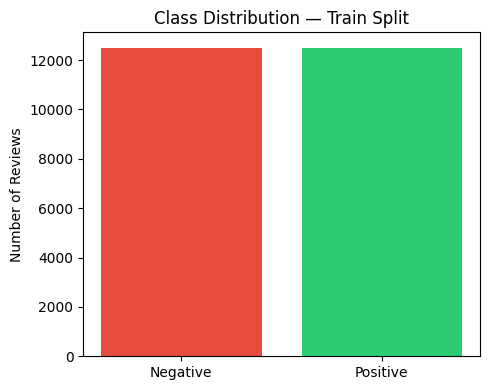


Avg review length (sample): 1351 characters


In [10]:
# ── Class distribution (train split)
class_dist_pd = train_df.groupBy('label').count().orderBy('label').toPandas()
class_dist_pd['sentiment'] = class_dist_pd['label'].map({0: 'Negative', 1: 'Positive'})
print(class_dist_pd)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(class_dist_pd['sentiment'], class_dist_pd['count'], color=['#e74c3c', '#2ecc71'])
ax.set_title('Class Distribution — Train Split')
ax.set_ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

# ── Review length sanity check
sample_lengths = train_df.limit(2000).toPandas()
sample_lengths['n_chars'] = sample_lengths['text_raw_html'].str.len()
print(f"\nAvg review length (sample): {sample_lengths['n_chars'].mean():.0f} characters")



---
##  Section 6 — Text Preprocessing

### Steps performed
| Step | Operation | Reason |
|------|-----------|--------|
| 1 | Strip HTML tags (`<br />` etc.) | IMDB reviews were scraped from web pages and contain markup |
| 2 | Lowercase | Treats `Great` and `great` as the same token |
| 3 | Remove non-alpha characters | Strips punctuation, numbers |
| 4 | Trim & collapse whitespace | Removes leading/trailing/extra spaces |

>  **Question:** Why is HTML-stripping a step you needed to *add* for IMDB that wasn't necessary for
> AG News? What would happen to the vocabulary if you skipped it?


In [18]:
def clean_text(df, in_col='text_raw_html', out_col='text'):
    if in_col not in df.columns:
        in_col = out_col  # already cleaned once — just re-run safely on 'text'
    return (
        df
        .withColumn(out_col, regexp_replace(col(in_col), r'<br\s*/?>', ' '))
        .withColumn(out_col, regexp_replace(col(out_col), r'<[^>]+>', ' '))
        .withColumn(out_col, lower(col(out_col)))
        .withColumn(out_col, regexp_replace(col(out_col), r'[^a-z\s]', ' '))
        .withColumn(out_col, trim(regexp_replace(col(out_col), r'\s+', ' ')))
        .drop(in_col) if in_col != out_col else df.withColumn(out_col, trim(regexp_replace(lower(col(out_col)), r'\s+', ' ')))
    )

---
##  Section 7 — Train / Test Split

Unlike the Guided Lab (where you had to create your own 80/20 split with `randomSplit`), IMDB
**already ships with a fixed, curator-defined train/test split** (25,000 / 25,000), which is what we
loaded in Section 4. We keep that official split rather than re-splitting, so results are comparable
to published benchmarks on this dataset.


  Train samples : 25,000  (50.0%)
  Test  samples : 25,000  (50.0%)


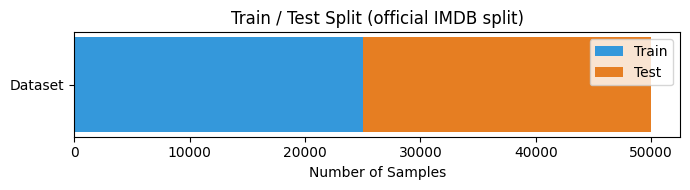

In [19]:
n_train = train_df.count()
n_test  = test_df.count()

print(f'  Train samples : {n_train:,}  ({n_train/(n_train+n_test)*100:.1f}%)')
print(f'  Test  samples : {n_test:,}  ({n_test/(n_train+n_test)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 2))
ax.barh(['Dataset'], [n_train], color='#3498db', label='Train')
ax.barh(['Dataset'], [n_test],  left=[n_train], color='#e67e22', label='Test')
ax.set_xlabel('Number of Samples')
ax.set_title('Train / Test Split (official IMDB split)')
ax.legend()
plt.tight_layout()
plt.show()


---
##  Section 8 — Feature Engineering: TF-IDF

Same pipeline stages as the Guided Lab: `Tokenizer → StopWordsRemover → HashingTF → IDF`.
As before, we **fit the featurizer on training data only** to avoid data leakage.


In [20]:
# ── Define TF-IDF pipeline stages
tokenizer = Tokenizer(inputCol='text', outputCol='tokens')
stop_rm   = StopWordsRemover(inputCol='tokens', outputCol='filtered')
hash_tf   = HashingTF(inputCol='filtered', outputCol='tf', numFeatures=2**18)  # 262,144
idf       = IDF(inputCol='tf', outputCol='features')

# ── Fit on TRAINING DATA ONLY (prevents leakage)
featurizer = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf])
feat_model = featurizer.fit(train_df)

# ── Transform both splits (for a quick peek — the full Pipeline below refits this per model)
train_fe = feat_model.transform(train_df)
test_fe  = feat_model.transform(test_df)

print('── Featurised sample ───────────────────')
train_fe.select('label', 'tokens', 'features').show(3, truncate=60)


── Featurised sample ───────────────────
+-----+------------------------------------------------------------+------------------------------------------------------------+
|label|                                                      tokens|                                                    features|
+-----+------------------------------------------------------------+------------------------------------------------------------+
|    1|[i, do, miss, the, company, vestron, they, sure, had, the...|(262144,[2437,2564,2701,3524,3785,4319,5150,8538,9781,137...|
|    1|[one, of, the, all, time, great, science, fiction, works,...|(262144,[5381,6110,18176,21823,23515,32817,51471,52226,53...|
|    1|[etienne, girardot, is, just, a, character, actor, the, s...|(262144,[2306,2307,3023,3898,5358,5429,5561,6558,6697,859...|
+-----+------------------------------------------------------------+------------------------------------------------------------+
only showing top 3 rows


---
##  Section 9 — Model Training: Linear SVM

The assessment brief requires a **Linear SVM (`LinearSVC`)** classifier. We wrap the full pipeline
(tokenizer → stopwords → TF-IDF → SVM) in a single Spark `Pipeline` so training data is featurised
and the model fit in one call, and the *same* fitted transformations are applied to the test set with
`.transform()`.


In [21]:
svm = LinearSVC(featuresCol='features', labelCol='label', maxIter=50, regParam=0.1)

print('  Training Linear SVM...')
t0 = time.time()
pipeline_svm = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, svm])
svm_model    = pipeline_svm.fit(train_df)
svm_pred     = svm_model.transform(test_df)
svm_time     = time.time() - t0
print(f'  Done in {svm_time:.1f}s')

svm_pred.select('label', 'prediction', 'rawPrediction').show(5)


  Training Linear SVM...
  Done in 79.8s
+-----+----------+--------------------+
|label|prediction|       rawPrediction|
+-----+----------+--------------------+
|    1|       1.0|[-3.2718027606449...|
|    1|       1.0|[-1.0187297060644...|
|    1|       0.0|[0.32936131850005...|
|    1|       1.0|[-1.7224732685556...|
|    1|       0.0|[0.71284550927387...|
+-----+----------+--------------------+
only showing top 5 rows


### (Optional) Logistic Regression baseline

The assessment brief only asks for Linear SVM, so this cell is **optional** — include it only if you
want a comparison point for the reflection questions (as in the Guided Lab). Skip it if you just need
the SVM results for submission.


In [22]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol='features', labelCol='label', maxIter=50)

print('  Training Logistic Regression baseline (optional)...')
t0 = time.time()
pipeline_lr = Pipeline(stages=[tokenizer, stop_rm, hash_tf, idf, lr])
lr_model    = pipeline_lr.fit(train_df)
lr_pred     = lr_model.transform(test_df)
lr_time     = time.time() - t0
print(f'  Done in {lr_time:.1f}s')


  Training Logistic Regression baseline (optional)...
  Done in 41.6s


---
## Section 10 — Model Evaluation

### Metrics Explained
| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Accuracy** | (TP+TN)/(TP+TN+FP+FN) | Overall correctness |
| **Precision** | TP/(TP+FP) | Of reviews predicted positive, how many really were |
| **Recall** | TP/(TP+FN) | Of truly positive reviews, how many were found |
| **F1 Score** | 2·(P·R)/(P+R) | Balance of precision & recall |

> Because IMDB is perfectly class-balanced (unlike AG News after binarising), accuracy is a more
> trustworthy headline metric here — but still report precision/recall/F1 as required.


In [23]:
acc_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='accuracy')
prec_eval = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedPrecision')
rec_eval  = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='weightedRecall')
f1_eval   = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction', metricName='f1')
auc_eval  = BinaryClassificationEvaluator(labelCol='label', rawPredictionCol='rawPrediction', metricName='areaUnderROC')

svm_acc  = acc_eval.evaluate(svm_pred)
svm_prec = prec_eval.evaluate(svm_pred)
svm_rec  = rec_eval.evaluate(svm_pred)
svm_f1   = f1_eval.evaluate(svm_pred)
svm_auc  = auc_eval.evaluate(svm_pred)

print('── Linear SVM — Test Set Performance ───')
print(f'Accuracy  : {svm_acc:.4f}')
print(f'Precision : {svm_prec:.4f}')
print(f'Recall    : {svm_rec:.4f}')
print(f'F1 Score  : {svm_f1:.4f}')
print(f'AUC-ROC   : {svm_auc:.4f}')
print(f'Train time: {svm_time:.1f}s')

results_pd = pd.DataFrame([{
    'Model': 'Linear SVM',
    'Accuracy': svm_acc, 'Precision': svm_prec, 'Recall': svm_rec,
    'F1': svm_f1, 'AUC': svm_auc, 'Train Time (s)': svm_time,
}])

# If you ran the optional LR cell above, this appends it for comparison
try:
    lr_acc  = acc_eval.evaluate(lr_pred)
    lr_prec = prec_eval.evaluate(lr_pred)
    lr_rec  = rec_eval.evaluate(lr_pred)
    lr_f1   = f1_eval.evaluate(lr_pred)
    lr_auc  = auc_eval.evaluate(lr_pred)
    results_pd = pd.concat([results_pd, pd.DataFrame([{
        'Model': 'Logistic Regression',
        'Accuracy': lr_acc, 'Precision': lr_prec, 'Recall': lr_rec,
        'F1': lr_f1, 'AUC': lr_auc, 'Train Time (s)': lr_time,
    }])], ignore_index=True)
except NameError:
    pass

results_pd


── Linear SVM — Test Set Performance ───
Accuracy  : 0.8532
Precision : 0.8532
Recall    : 0.8532
F1 Score  : 0.8532
AUC-ROC   : 0.9205
Train time: 79.8s


,Model,Accuracy,Precision,Recall,F1,AUC,Train Time (s)
0,Linear SVM,0.85316,0.853210,0.85316,0.853155,0.920521,79.803668
1,Logistic Regression,0.82012,0.820306,0.82012,0.820094,0.886610,41.591144


---
##  Section 11 — Confusion Matrix

```
              Predicted
              Neg   Pos
         ┌──────┬──────┐
  True   │  TN  │  FP  │   ← Negative reviews
  Pos    ├──────┼──────┤
         │  FN  │  TP  │   ← Positive reviews
         └──────┴──────┘
```

- **TN**: Negative review correctly classified as negative
- **FP**: Negative review wrongly classified as positive
- **FN**: Positive review wrongly classified as negative
- **TP**: Positive review correctly classified as positive


/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:157: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


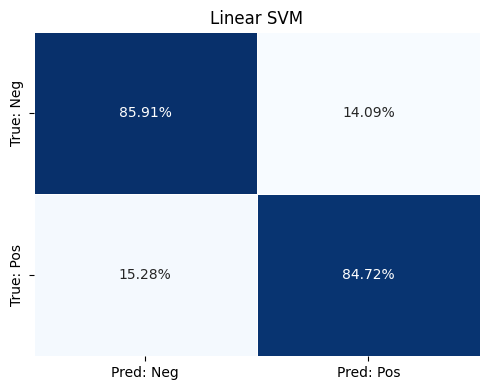

Raw counts (rows=true, cols=predicted):
[[10739.  1761.]
 [ 1910. 10590.]]


In [24]:
def plot_confusion_matrix(pred_df, model_name, ax):
    rdd = pred_df.select('prediction', 'label').rdd.map(
        lambda r: (float(r[0]), float(r[1]))
    )
    cm_metrics = MulticlassMetrics(rdd)
    cm = cm_metrics.confusionMatrix().toArray()
    cm_norm = cm / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt='.2%',
        cmap='Blues', ax=ax,
        xticklabels=['Pred: Neg', 'Pred: Pos'],
        yticklabels=['True: Neg', 'True: Pos'],
        linewidths=0.5, cbar=False,
    )
    ax.set_title(model_name)
    return cm

fig, ax = plt.subplots(figsize=(5, 4))
cm_svm = plot_confusion_matrix(svm_pred, 'Linear SVM', ax)
plt.tight_layout()
plt.show()

print('Raw counts (rows=true, cols=predicted):')
print(cm_svm)
